# Notebook 06 — Model Evaluation and Predictions

This notebook evaluated model performance using metrics such as AUC and precision-recall, and predictions are generated to classify employees into risk categories. Additionally this notebook deploys the trained model using Amazon SageMaker and generates predictions for new data. 
The output includes employee-level risk scores that can support data-driven retention strategies.



In [1]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import io
import xgboost as xgb
import tarfile
import os

s3 = boto3.client("s3")

from sagemaker.tuner import HyperparameterTuner
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

#Setup

session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = session.boto_region_name
s3 = boto3.client("s3", region_name=region)

bucket = "ads508-team-4-private"

print("Region:", region)
print("Role:", role)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Region: us-east-1
Role: arn:aws:iam::802896854792:role/LabRole


In [2]:
# get tuning job
tuning_job_name = "sagemaker-xgboost-260413-0713"

In [3]:
tuner = HyperparameterTuner.attach(
    tuning_job_name=tuning_job_name,
    sagemaker_session=session
)

print("Attached to tuning job:", tuning_job_name)

Attached to tuning job: sagemaker-xgboost-260413-0713


In [4]:
best_job_name = tuner.best_training_job()
print("Best training job:", best_job_name)

best_estimator = tuner.best_estimator()
print("Best estimator:", best_estimator.model_data)

Best training job: sagemaker-xgboost-260413-0713-006-3b42dbda

2026-04-13 07:17:38 Starting - Found matching resource for reuse
2026-04-13 07:17:38 Downloading - Downloading the training image
2026-04-13 07:17:38 Training - Training image download completed. Training in progress.
2026-04-13 07:17:38 Uploading - Uploading generated training model
2026-04-13 07:17:38 Completed - Resource reused by training job: sagemaker-xgboost-260413-0713-009-9d2c5784
Best estimator: s3://ads508-team-4-private/model-artifacts/sagemaker-xgboost-260413-0713-006-3b42dbda/output/model.tar.gz


In [5]:
# load data
test_path = f"s3://{bucket}/processed/test_attrition_data.csv"
test_df = pd.read_csv(test_path)

print("Test shape:", test_df.shape)
print(test_df.head())

Test shape: (1147, 28)
   Age  DistanceFromHome  JobInvolvement  JobLevel  JobSatisfaction  \
0   48                44               3         2                1   
1   57                26               3         3                2   
2   59                29               4         5                5   
3   20                29               4         3                5   
4   37                37               3         5                5   

   EnvironmentSatisfaction  RelationshipSatisfaction  WorkLifeBalance  \
0                        2                         2                3   
1                        2                         1                1   
2                        3                         3                2   
3                        2                         1                1   
4                        1                         2                3   

   MonthlyIncome  NumCompaniesWorked  ...    salary_gap  OverTime_Yes  \
0           4992                   1  

In [6]:
# keep same selected features for testing
selected_features = [
    'MonthlyIncome',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'Age',
    'NumCompaniesWorked',
    'DistanceFromHome',
    'salary_gap',
    'external_job_demand',
    'StagnationScore',
    'SatisfactionIndex',
    'NoRecentPromotion',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'WorkLifeBalance',
    'JobLevel',
    'OverTime_Yes',
    'JobRole_Sales Representative',
    'JobRole_Laboratory Technician',
    'JobRole_Human Resources',
    'JobRole_Research Director',
    'MaritalStatus_Single',
]

selected_features = [c for c in selected_features if c in test_df.columns]

target_col = "Attrition"

X_test = test_df[selected_features].copy()
y_test = test_df[target_col].astype(int).copy()

print("Selected feature count:", len(selected_features))
print("X_test shape:", X_test.shape)
print("Attrition rate:", y_test.mean())

Selected feature count: 19
X_test shape: (1147, 19)
Attrition rate: 0.1944202266782912


### Deploy the best model and generate predictions

In [19]:
# deploy the best model
predictor = best_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    serializer=CSVSerializer(),
    deserializer=CSVDeserializer()
)

print("Endpoint deployed:", predictor.endpoint_name)

------!Endpoint deployed: sagemaker-xgboost-2026-04-13-07-28-58-994


In [27]:
# generate predictions

csv_payload = X_test.to_csv(index=False, header=False)

# Predict probabilities
predictions = predictor.predict(csv_payload)
y_pred_prob = np.array([float(row[0]) for row in predictions])

# Convert probabilities to class labels
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Predictions generated:", len(y_pred_prob))
print("First 10 probabilities:", y_pred_prob[:10])

Predictions generated: 1147
First 10 probabilities: [0.54398245 0.54661143 0.51104003 0.53994727 0.4793579  0.49769291
 0.44756415 0.47902045 0.55593348 0.4828347 ]


In [28]:
# evalaute
auc_roc = roc_auc_score(y_test, y_pred_prob)
avg_prc = average_precision_score(y_test, y_pred_prob)

print("=" * 55)
print("TalentIQ — TEST SET EVALUATION")
print("=" * 55)
print(f"AUC-ROC Score       : {auc_roc:.4f}")
print(f"Avg Precision Score : {avg_prc:.4f}")
print("=" * 55)
print()
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"]
))

TalentIQ — TEST SET EVALUATION
AUC-ROC Score       : 0.5437
Avg Precision Score : 0.2205

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.81      0.58      0.68       924
   Attrition       0.20      0.45      0.28       223

    accuracy                           0.55      1147
   macro avg       0.51      0.51      0.48      1147
weighted avg       0.69      0.55      0.60      1147



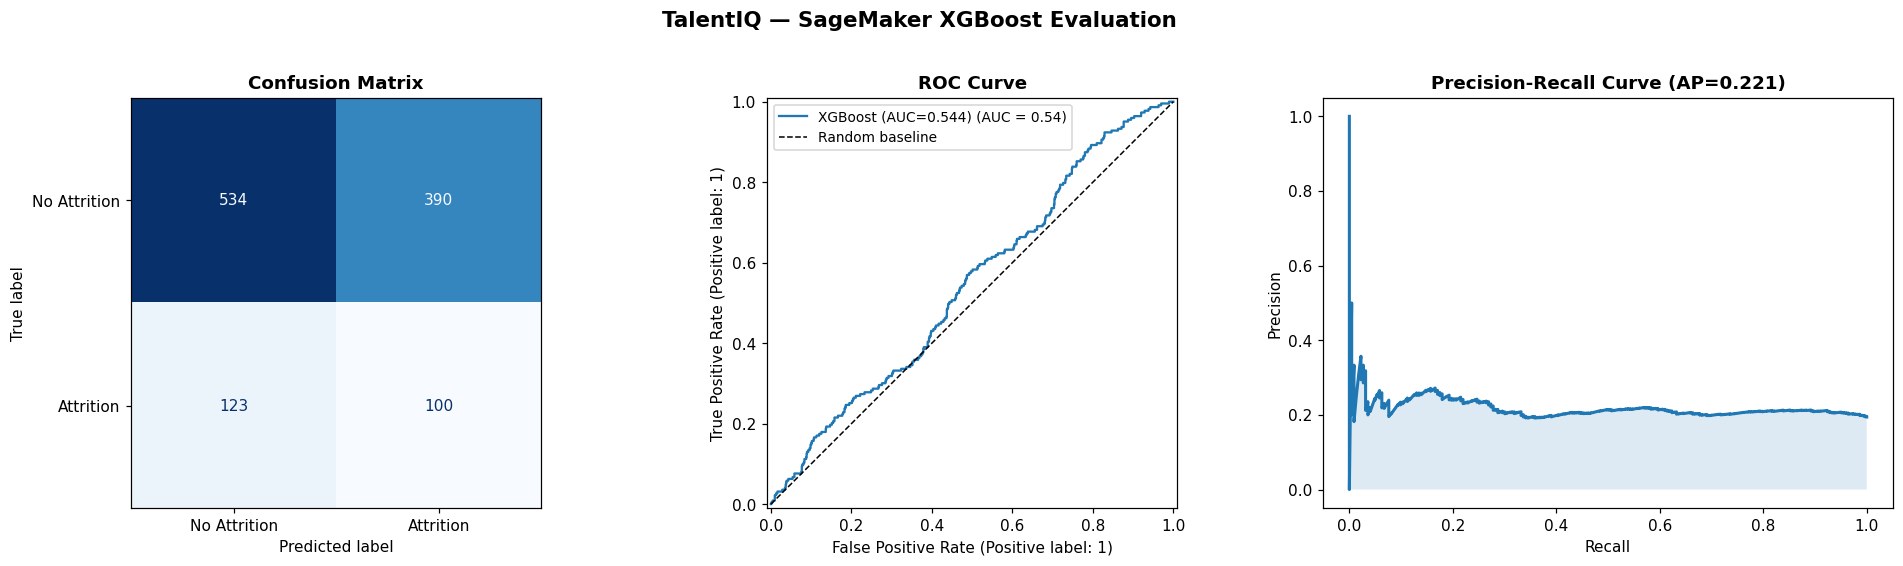

In [29]:
#plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_prob,
    ax=axes[1],
    name=f"XGBoost (AUC={auc_roc:.3f})"
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
axes[1].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(recall, precision, linewidth=2)
axes[2].fill_between(recall, precision, alpha=0.15)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title(f"Precision-Recall Curve (AP={avg_prc:.3f})", fontsize=12, fontweight="bold")

plt.suptitle("TalentIQ — SageMaker XGBoost Evaluation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/tmp/model_evaluation.png", bbox_inches="tight")
plt.show()

In [30]:
# generate employee risks score
risk_df = pd.DataFrame({
    "EmployeeIndex": range(len(y_pred_prob)),
    "ActualAttrition": y_test.values,
    "AttritionRisk": np.round(y_pred_prob, 4),
    "PredictedClass": y_pred
})

risk_df["RiskTier"] = pd.cut(
    risk_df["AttritionRisk"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

risk_df = risk_df.sort_values("AttritionRisk", ascending=False).reset_index(drop=True)

print("Risk Score Distribution:")
print(risk_df["RiskTier"].value_counts())

print("\nTop 10 highest-risk employees:")
print(risk_df.head(10).to_string(index=False))

Risk Score Distribution:
RiskTier
Medium    1133
Low          7
High         7
Name: count, dtype: int64

Top 10 highest-risk employees:
 EmployeeIndex  ActualAttrition  AttritionRisk  PredictedClass RiskTier
           105                0         0.7933               1     High
           290                1         0.7447               1     High
           149                0         0.6992               1     High
           606                0         0.6921               1     High
           769                0         0.6849               1     High
           692                1         0.6747               1     High
           904                0         0.6074               1     High
           750                0         0.5997               1   Medium
           421                0         0.5986               1   Medium
           254                0         0.5903               1   Medium


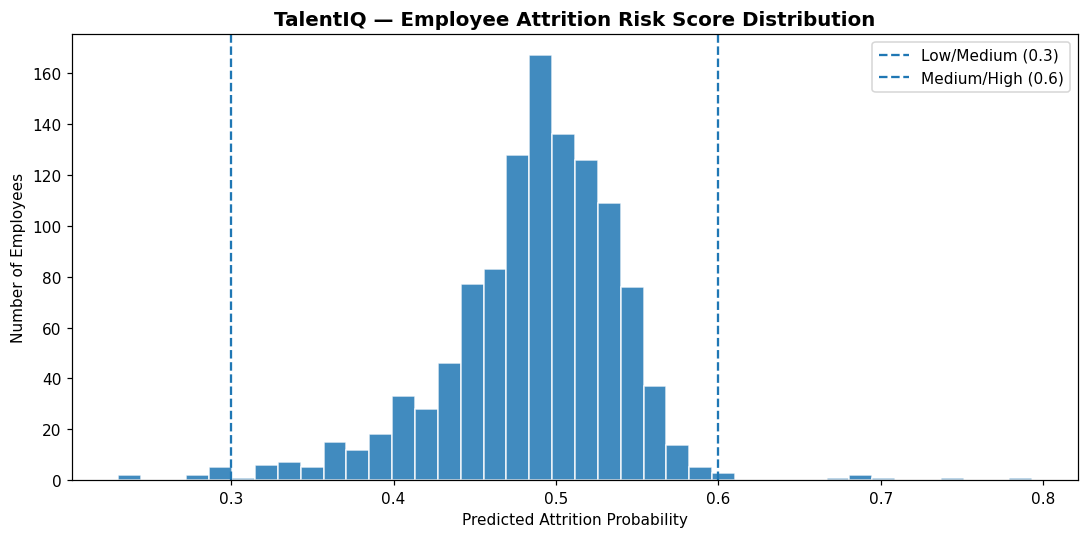

In [31]:
# plot score risk 
plt.figure(figsize=(10, 5))
plt.hist(risk_df["AttritionRisk"], bins=40, edgecolor="white", alpha=0.85)
plt.axvline(0.3, linestyle="--", linewidth=1.5, label="Low/Medium (0.3)")
plt.axvline(0.6, linestyle="--", linewidth=1.5, label="Medium/High (0.6)")
plt.xlabel("Predicted Attrition Probability")
plt.ylabel("Number of Employees")
plt.title("TalentIQ — Employee Attrition Risk Score Distribution", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/risk_scores.png", bbox_inches="tight")
plt.show()

s3://ads508-team-4-private/model-artifacts/sagemaker-xgboost-260413-0713-006-3b42dbda/output/model.tar.gz
['dask-scratch-space', 'num_distributions.png', 'boxplots_by_attrition.png', 'cat_attrition_rates.png', 'train_xgb.csv', 'validation_xgb.csv', 'test_xgb.csv', 'model_evaluation.png', 'risk_scores.png', 'model.tar.gz', 'xgboost-model', 'sagemaker-recovery-mode-home', 'download_amazon_q_agentic_chat_artifacts.sh', 'extract_amazon_q_agentic_chat_urls.py']
                Feature  Importance
8   external_job_demand   20.515949
17         OverTime_Yes   17.165510
0         MonthlyIncome   16.289671
6      DistanceFromHome   15.595617
10    SatisfactionIndex   13.827841
2    YearsInCurrentRole   12.877130
15      WorkLifeBalance   12.712947
7            salary_gap   12.642509
5    NumCompaniesWorked   12.281322
4                   Age   12.033966


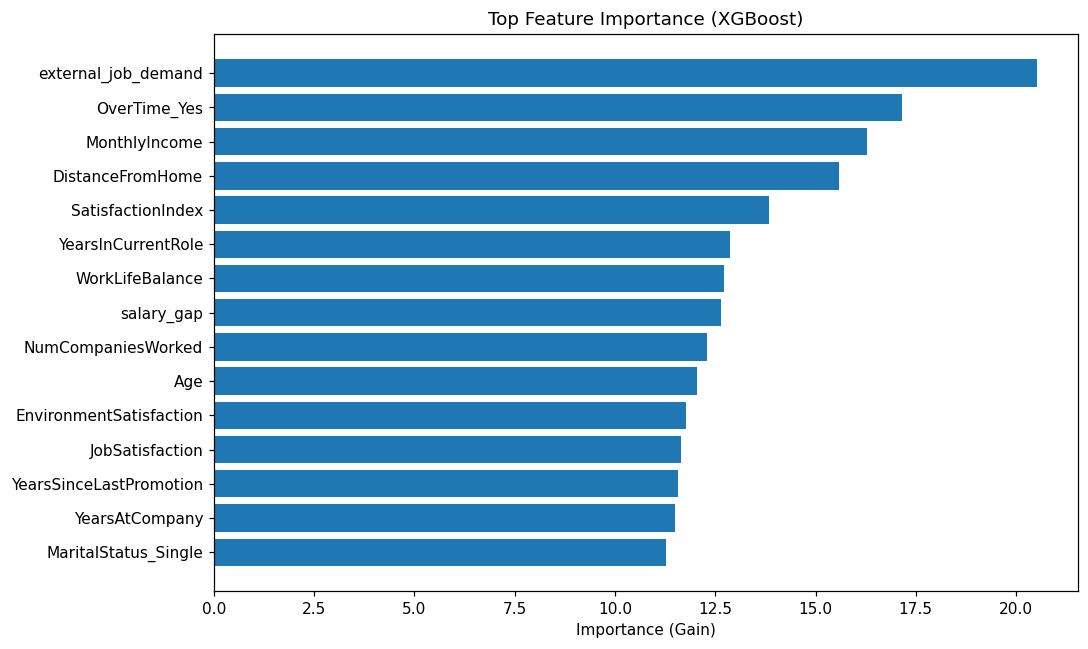

In [32]:
# plot feature importance
model_artifact = best_estimator.model_data  
print(model_artifact)


# Parse S3 path
bucket_name = model_artifact.split("/")[2]  
key = "/".join(model_artifact.split("/")[3:]) 

local_model_path = "/tmp/model.tar.gz"

# Download & extract
s3.download_file(bucket_name, key, local_model_path)

with tarfile.open(local_model_path) as tar:
    tar.extractall(path="/tmp/")

print(os.listdir("/tmp/")) 

booster = xgb.Booster()
booster.load_model("/tmp/xgboost-model")

importance_dict = booster.get_score(importance_type="gain")
feature_names = selected_features  # must match training order

importance_df = pd.DataFrame({
    "Feature": [feature_names[int(k[1:])] for k in importance_dict.keys()],
    "Importance": list(importance_dict.values())
}).sort_values("Importance", ascending=False)

print(importance_df.head(10))

import matplotlib.pyplot as plt

top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance (Gain)")
plt.title("Top Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

In [33]:
# save
risk_df.to_csv("/tmp/employee_risk_scores.csv", index=False)

outputs = [
    ("/tmp/employee_risk_scores.csv", "models/employee_risk_scores.csv"),
    ("/tmp/model_evaluation.png", "models/model_evaluation.png"),
    ("/tmp/risk_scores.png", "models/risk_scores.png"),
]

for local, key in outputs:
    try:
        s3.upload_file(local, bucket, key)
        print(f"Uploaded -> s3://{bucket}/{key}")
    except Exception as e:
        print(f"Could not upload {key}: {e}")

Uploaded -> s3://ads508-team-4-private/models/employee_risk_scores.csv
Uploaded -> s3://ads508-team-4-private/models/model_evaluation.png
Uploaded -> s3://ads508-team-4-private/models/risk_scores.png


### Close endpoint

In [34]:
# DELETE ENDPOINT
predictor.delete_endpoint(delete_endpoint_config=True)
print("Endpoint deleted.")

Endpoint deleted.
